# **Nettoyage des données et statistiques descriptives**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from sklearn.impute import KNNImputer

### **0. Importation des données**

In [ ]:
!pip install pyreadstat
import s3fs
import pandas as pd
import tempfile
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "gbern13"

FILE_PATH_S3 = f"{MY_BUCKET}/diffusion/PISA2022/student_questionnaire/CY08MSP_STU_QQQ.SAV"
with fs.open(FILE_PATH_S3, "rb") as s3f:
    with tempfile.NamedTemporaryFile(suffix=".sav") as tmp:
        tmp.write(s3f.read())
        tmp.flush()
        df = pd.read_spss(tmp.name)

print(df.head())

8718.46s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Le dataset contient plus de 1200 variables et plus de 600 000 observations. 
Pour alléger le jeu de données et faciliter l'analyse qui sera menée au cours du projet il est nécessaire de nettoyer le jeu de données. 


### **I. Nettoyage du dataset et preprocessing**

L'objectif de cette première partie est d'obtenir un jeu de données propre qui permettra ensuite de se familiariser avec les données au travers d'une analyse descriptive et enfin d'effectuer une première modélisation qui tentera de répondre à la problématique. 

#### 1. **Premier choix des variables**

Le dataset importé contient plus de 1200 variables. La majorité de ces variables sont issues directement des questionnaires adressés aux étudiants. Pour un même facteur explicatif de la créativité d'un élève, on peut associer plusieurs questions qui permettent dy répondre. Il faudrait alors créer pour chaque facteur créer une variable synthétique à partir des variables disponibles dans le dataset. Ces variables synthétiques dérivées sont également disponibles dans le dataset et sont au nombre de 86. 

Cette partie présente l'ensemble des variables choisies pour répondre au mieux à la problématique du sujet. 

In [ ]:
## Liste contenant les variables choisies 
variables=['CNTSTUID','ST004D01T','ESCS','LANGN','EXERPRAC','WORKPAY','WORKHOME','ICTRES','BULLIED',
'SCHRISK','FAMSUP','TEACHSUP','PARINVOL','SCHSUST','CREATOOS','CREATAS','EXPO21ST','FEELSAFE','DISCLIM','COGACMCO']
## Réduction du dataset à ces variables 
data=df[variables].copy()
## Nouveaux noms des variables 
renom=['id','gender','society','home_language','sport','work','household_care','digital_home',
'social','school_safety','family_support','teacher_support','parent_invol','school_support','creative_out',
'creative_at','math_reasoning','safety','climate_math','math_thinking']
## Renommage des variables
data.columns=renom
data.head()


,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
0,800001.0,Female,1.1112,Albanian,No exercise or sports,No work for pay,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962
1,800002.0,Male,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN
2,800003.0,Male,-0.1867,Albanian,NaN,No work for pay,No work in household or care of family members,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN
3,800005.0,Female,-3.2198,Albanian,10 or more times of exercising or sports per week,No work for pay,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,-0.7468,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216
4,800006.0,Female,-1.0548,Albanian,2 times of exercising or sports per week,No work for pay,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927


Justification du choix des variables : 
Parmi l'ensemble des variables synthétiques disponibles, plusieurs variables différentes peuvent être utilisées comme variable explicative. Néanmoins, certaines d'entre elles ne sont pas adaptées en raison d'une distribution qui ne contient pas assez d'informations par exemple. 

Comparons par exemple les variables **ICTRES** ('nouveau nom de la variable') et **ICTHOME**

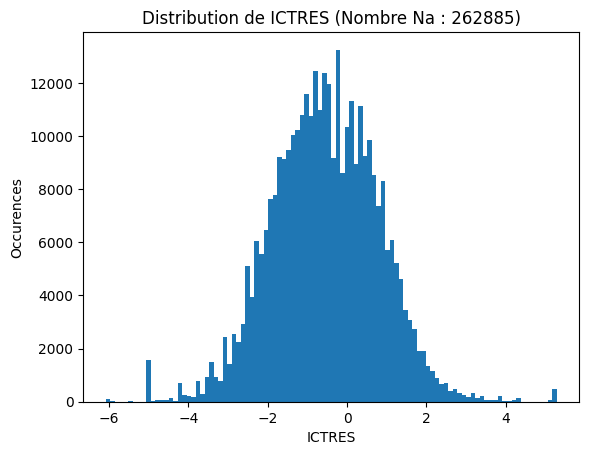

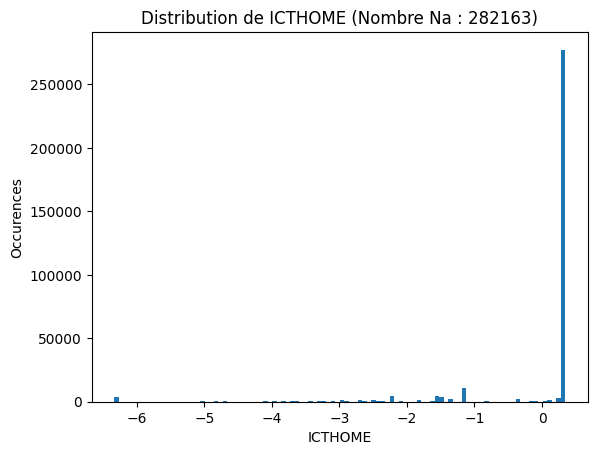

In [ ]:
ictres,icthome=df['ICTRES'],df['ICTHOME']
ictres_na,icthome_na=ictres.isna().sum(),icthome.isna().sum()
# Distribution ICTRES
plt.hist(ictres,bins=100)
plt.xlabel('ICTRES')
plt.ylabel('Occurences')
plt.title('Distribution de ICTRES '+f'(Nombre Na : {ictres_na})')
plt.show()
# Distribution ICTHOME 
plt.hist(icthome,bins=100)
plt.xlabel('ICTHOME')
plt.ylabel('Occurences')
plt.title('Distribution de ICTHOME '+f'(Nombre Na : {icthome_na})')
plt.show()

In [ ]:
# Nombre d'occurence des valeurs prises par ces deux variables 
ictres_count=ictres.value_counts()
icthome_count=icthome.value_counts()
ictres_count,icthome_count

(ICTRES
 -0.2035    2866
 -0.4979    2436
 -0.5542    1990
 -0.8053    1916
  0.1083    1429
            ... 
  4.2096       1
  4.2365       1
  4.2450       1
  4.2846       1
  4.3014       1
 Name: count, Length: 40459, dtype: int64,
 ICTHOME
  0.3346    274384
 -1.1402     11095
 -1.5118      3886
 -6.3292      3830
 -2.2168      2933
             ...  
 -4.4253         1
 -4.4221         1
 -4.4062         1
 -1.4106         1
 -6.2014         1
 Name: count, Length: 488, dtype: int64)

In [ ]:
# Nombre de valeurs de ICTHOME qui apparaissent au moins 2900 fois
len(icthome_count[icthome_count>=2900])

5

In [ ]:
# Part d'observations dont la valeur ICTHOME prend une des 5 valeurs les plus présente
p=round(icthome_count[icthome_count>=2900].sum()/icthome_count.sum()*100,2)
print(f'5 valeurs de la variables ICTHOME sont prises par {p} % des observations du dataset.')

5 valeurs de la variables ICTHOME sont prises par 89.31 % des observations du dataset.


Bien que les deux variables ICTRES et ICTHOME nous donnent accès à la même information, i.e l'accès un certains nombre d'appareils digitaux au sein du foyer, la variables ICTHOME est beaucoup moins pertinente. En effet, on voit que cette dernière contient beaucoup moins d'information. La variable ICTHOME est une variable qui prend des valeurs continues. Cependant, dans l'échantillon considéré, cette variable est principalement représentée par seulement 5 valeurs différentes ce qui est bien trop peu sur un échantillon de plus de 600 000 observations. 

#### 2. **Traitement des identifiants**

On vérifie que chaque identifiant présent dans le jeu de donnée est bien associé à une unique observation

In [ ]:
id_count=data['id'].value_counts().sort_values(ascending=False)
id_count.head()

id
800001.0    1
800002.0    1
800003.0    1
800005.0    1
800006.0    1
Name: count, dtype: int64

#### 3. **Recodage des variables qualitatives**

L'un des objectifs de ce projet est d'expliquer la créativité des élèves à partir de plusieurs facteurs choisis précédemment. Pour ce faire, nous utiliserons certains modèles de régression notamment la régression linéaire. 

Il est donc primordial de recoder les variables qualitatives en variables quantitatives afin de pouvoir les considérer par la suite. 

Les seules variables qualitatives du dataset sont les variables : *gender*, *home_language*, *sport*, *work* et *household_care*

Recodage des variables

*gender*

In [ ]:
data['gender'].nunique()

2

Cette variable est binaire, on peut donc la recoder en 0 pour les labels 'Male' et 1 pour les labels 'Female'

In [ ]:
data['gender']=data['gender'].replace({'Male':0,'Female':1})

/tmp/ipykernel_7209/3507592353.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['gender']=data['gender'].replace({'Male':0,'Female':1})
/tmp/ipykernel_7209/3507592353.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['gender']=data['gender'].replace({'Male':0,'Female':1})


*sport*

In [ ]:
data['sport'].value_counts()

sport
No exercise or sports                                110142
10 or more times of exercising or sports per week    108484
4 times of exercising or sports per week              61081
2 times of exercising or sports per week              60960
5 times of exercising or sports per week              54464
6 times of exercising or sports per week              49799
3 times of exercising or sports per week              45241
8 times of exercising or sports per week              31265
1 time of exercising or sports per week               27020
7 times of exercising or sports per week              15466
9 times of exercising or sports per week               9950
Name: count, dtype: int64

La variable *sport* prend ses 11 valeurs distinctes (la fréquence d'activité sportive hebdomadaire). On peut recoder chaque label par la fréquence hebdomadaire d'activité sportive. 

In [ ]:
data['sport']=data['sport'].str[:2].copy()
data['sport']=data['sport'].replace({'No':0})
data['sport']=data['sport'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
0,800001.0,1,1.1112,Albanian,0.0,No work for pay,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN
2,800003.0,0,-0.1867,Albanian,NaN,No work for pay,No work in household or care of family members,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN
3,800005.0,1,-3.2198,Albanian,10.0,No work for pay,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,-0.7468,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216
4,800006.0,1,-1.0548,Albanian,2.0,No work for pay,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927


*work*

In [ ]:
data['work'].value_counts()

work
No work for pay                                 401767
2 times of working for pay per week              32076
10 or more times of working for pay per week     27949
1 time of working for pay per week               21371
4 times of working for pay per week              19966
5 times of working for pay per week              18603
3 times of working for pay per week              15519
6 times of working for pay per week              12647
8 times of working for pay per week               7325
7 times of working for pay per week               5188
9 times of working for pay per week               3091
Name: count, dtype: int64

De façon similaire :

In [ ]:
data['work']=data['work'].str[:2].copy()
data['work']=data['work'].replace({'No':0})
data['work']=data['work'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
0,800001.0,1,1.1112,Albanian,0.0,0.0,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN
2,800003.0,0,-0.1867,Albanian,NaN,0.0,No work in household or care of family members,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN
3,800005.0,1,-3.2198,Albanian,10.0,0.0,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,-0.7468,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216
4,800006.0,1,-1.0548,Albanian,2.0,0.0,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927


*household_care*

In [ ]:
data['household_care'].value_counts()

household_care
10 or more times of working in household or caring for family members per week    151254
No work in household or care of family members                                     70722
5 times of working in household or caring for family members per week              63791
2 times of working in household or caring for family members per week              51211
4 times of working in household or caring for family members per week              49942
6 times of working in household or caring for family members per week              45191
3 times of working in household or caring for family members per week              40177
8 times of working in household or caring for family members per week              34116
1 time of working in household or caring for family members per week               26973
7 times of working in household or caring for family members per week              23232
9 times of working in household or caring for family members per week              17200
Name: 

De façon analogue

In [ ]:
data['household_care']=data['household_care'].str[:2].copy()
data['household_care']=data['household_care'].replace({'No':0})
data['household_care']=data['household_care'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
0,800001.0,1,1.1112,Albanian,0.0,0.0,10.0,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN
2,800003.0,0,-0.1867,Albanian,NaN,0.0,0.0,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN
3,800005.0,1,-3.2198,Albanian,10.0,0.0,10.0,-2.1392,0.9885,-0.6386,-0.7468,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216
4,800006.0,1,-1.0548,Albanian,2.0,0.0,4.0,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927


In [ ]:
data.dtypes

id                  float64
gender             category
society            category
home_language      category
sport               float64
work                float64
household_care      float64
digital_home       category
social             category
school_safety      category
family_support     category
teacher_support    category
parent_invol       category
school_support     category
creative_out       category
creative_at        category
math_reasoning     category
safety             category
climate_math       category
math_thinking      category
dtype: object

Toutes les variables sont catégorielle. Afin de pouvoir effectuer une régression par la suite il est nécessaire de les convertir en variables numériques. 

In [ ]:
# Convertir toutes les colonnes en numérique (sauf id)
for col in data.columns:
    if col != 'id':
        data[col] = pd.to_numeric(data[col], errors='coerce')

#### 4. **Traitement des valeurs manquantes**

Le traitement des valeurs manquantes est primordial. En effet, une valeur manquante peut provenir d'une erreur de saisie comme elle peut être volontaire. 

Une première partie s'intéresse à la distribution des valeurs manquantes au sein du dataset ainsi qu'à leurs sources notamment au travers d'un test Little qui permet d'évaluer si les données manquantes sont complètement aléatoires. 

Une seconde partie permettra en conséquence de traiter ces valeurs manquantes de deux façons différentes. 

##### 4.1 **Distribution des valeurs manquantes et test Little**


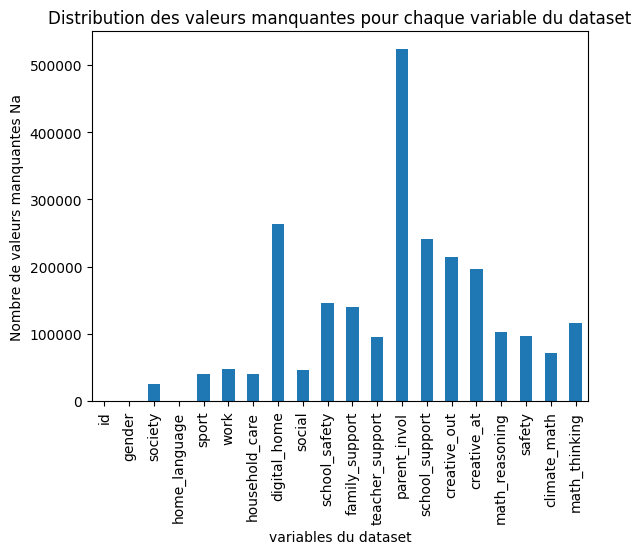

In [ ]:
### Distribution des Na ### 
data_count_na=data.isna().sum()
data_count_na.plot(kind='bar')
plt.xlabel('variables du dataset')
plt.ylabel('Nombre de valeurs manquantes Na')
plt.title('Distribution des valeurs manquantes pour chaque variable du dataset')
plt.show()
## Distribution des Na sur l'ensemble du dataset
## Distribution des Na par variables 
## Nombre d'observations sans Na 

In [ ]:
data=data.drop(columns=['parent_invol'])

On remarque que la variable digital_home présente également une proportion importante de valeurs manquantes. Cette variable étant centrale pour notre problématique, nous ne pouvons ni la supprimer, ni supprimer les lignes concernées sinon cela entraînerait une perte trop importante de données et un biais de sélection majeur. Il est donc nécessaire de savoir si l'absence de réponse est corrélée aux caractéristiques des individus. Si l'absence de réponse n'est pas aléatoire, une imputations par la moyenne ou la médiane ne serait pas adaptée car elle ne préserverait pas les relations entre les variables. 
Ainsi, afin de tester si les données sont MCAR (Missing Completely At Random), nous comparons les moyennes des autres variables entre les groupes d'élèves ayant renseigné digital_home et celui ne l'ayant pas renseigné. Des différences significatives indiqueraient que les valeurs manquantes dépendraient d'autres caractéristiques observables et justifieront l'utilisation d'une méthode d'imputation plus sophistiquée. 

On effectue le test seulement sur ces 7 variables qui présentent peu de valeurs manquantes et sont représentatives du profil socio-économique des élèves.

In [ ]:
print("="*60)
print("TEST MCAR - digital_home")
print("="*60)

has_digital = data['digital_home'].notna()
group_with = data[has_digital]
group_without = data[~has_digital]

print(f"\nAvec digital_home: {len(group_with):,} obs")
print(f"Sans digital_home: {len(group_without):,} obs\n")

test_vars = ['society', 'sport', 'work', 'household_care', 'creative_out', 'gender','social']

results = []
for var in test_vars:
    present = group_with[var].dropna()
    missing = group_without[var].dropna()
    
    if len(present) > 100 and len(missing) > 100:
        _, p = ttest_ind(present, missing)
        diff = present.mean() - missing.mean()
        
        results.append({
            'Variable': var,
            'Différence': f"{diff:.3f}",
            'p-value': f"{p:.4f}",
            'Signif': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'NS'
        })

import pandas as pd
print(pd.DataFrame(results).to_string(index=False))

nb_sig = sum(1 for r in results if r['Signif'] != 'NS')
print(f"\n{nb_sig}/{len(results)} variables significatives → {'Pas MCAR' if nb_sig > 0 else 'MCAR possible'}") 

TEST MCAR - digital_home

Avec digital_home: 350,859 obs
Sans digital_home: 262,885 obs

      Variable Différence p-value Signif
       society     -0.413  0.0000    ***
         sport      0.179  0.0000    ***
          work      0.601  0.0000    ***
household_care      0.125  0.0000    ***
  creative_out      0.227  0.0000    ***
        gender      0.011  0.0000    ***
        social      0.202  0.0000    ***

7/7 variables significatives → Pas MCAR


On en conclut que les données ne sont pas MCAR sur ces variables, ainsi la probabilité qu'une valeur soit manquante dépend d'autres variables observées. 

Nous aurons donc recours aux KNN afin de traiter les valeurs manquantes du data set. Les KNN sont l'algorithme des proches voisins. Il s'agit d'une méthode d'apprentissage supervisé qui remplace chaque valeur manquante en identifiant les K observations les plus similaires selon les autres variables, puis en calculant leur moyenne. Avec K=5, nous utilisons les 5 élèves les plus proches en terme de profil pour imputer les valeurs manquantes.

Dataset sur lequel se feront les analyses descriptives

In [ ]:
data_clean=data.copy()

La variable parent_invol contient beaucoup trop de valeurs manquantes. Cela vient du fait qu'il s'agit de la seule variable du datatset *data* qui provient du questionnaire donné aux parents de chaque élève et auquel moins de 100 000 d'entre eux sur 600 000 ont répondu. 

Dans un premier temps, nous travaillerons sans cette variable afin de garder un échantillon le plus gros possible. 


##### 4.2 **Imputation des valeurs manquantes**

En les retirant (possible grâce à la partie précédente)

In [13]:
## drop.na
## df.shape

En imputant les valeurs moyennes

In [14]:
## Remplace les valeurs Na par la moyenne 

Distribution des Na selon les pays (OCDE ou non ?)

In [15]:
## Distribution des Na selon le pays 
## Créer une carte pour voir la répartition des pays (mettre pays OCDE et non OCDE)

Exportation du jeu de données propre dans le bucket S3 

In [16]:
## dataset_final = ..
## export in S3 as CSV 

### **II. Statistiques descriptives sur le jeu de données**

L'objectif de cette partie est de se familiariser avec le dataset utilisé au travers de statistiques descriptives. 

In [20]:
## Dataset à utiliser
data_clean.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
0,800001.0,1,1.1112,Albanian,0.0,0.0,10.0,4.9507,-1.2280,-0.6386,1.8355,1.5558,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN
2,800003.0,0,-0.1867,Albanian,NaN,0.0,0.0,0.4307,NaN,-0.6386,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN
3,800005.0,1,-3.2198,Albanian,10.0,0.0,10.0,-2.1392,0.9885,-0.6386,-0.7468,1.5558,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216
4,800006.0,1,-1.0548,Albanian,2.0,0.0,4.0,-0.5542,-1.2280,-0.6386,-0.5122,0.1475,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927


1. Vision globale de notre data set

In [35]:
data_clean.describe(include='all')

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,family_support,teacher_support,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking
count,6.137440e+05,613665.0,588276.0000,613744,573872.000000,565502.000000,573809.000000,350859.0000,567981.000,467615.0000,473099.0000,517729.0000,372826.0000,399028.0000,417643.000,510581.0000,517188.000,542833.0000,497097.0000
unique,NaN,2.0,55630.0000,239,NaN,NaN,NaN,40459.0000,15564.000,304.0000,30931.0000,71.0000,23024.0000,22284.0000,23285.000,32283.0000,499.000,3808.0000,27312.0000
top,NaN,0.0,0.6952,Spanish,NaN,NaN,NaN,-0.2035,-1.228,-0.6386,2.1939,1.5558,1.3147,-0.8105,-1.117,0.4227,-0.756,-0.1219,0.2085
freq,NaN,307906.0,38.0000,99330,NaN,NaN,NaN,2866.0000,254441.000,271305.0000,1265.0000,139711.0000,1335.0000,134877.0000,80495.000,1070.0000,160437.000,3748.0000,1038.0000
mean,4.342643e+07,NaN,NaN,NaN,4.587910,1.384727,5.476887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.548515e+07,NaN,NaN,NaN,3.528148,2.729513,3.552691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.000010e+05,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.140198e+07,NaN,NaN,NaN,2.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.981988e+07,NaN,NaN,NaN,4.000000,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,6.880501e+07,NaN,NaN,NaN,8.000000,2.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La fonction describe nous donne un premier aperçu de notre data set et de la répartition des données.

2. Histogramme variables de créativité

La variable creative_out présente une très forte asymétrie à gauche. Crative_at est plus normalement distribuée. Nous pouvons donc faire un test de normalité de la distribution.

In [ ]:
#Test de normalité creative_at
